In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [3]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [4]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [5]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [6]:
df = df.sort_values('datetime').reset_index(drop=True)
df2=df.copy()

In [7]:
df=df[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station', 'aqi']]

In [8]:
df

,year,month,day,hour,is_weekend,season,station,aqi
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",500
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",399
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",500
3,2020,1,1,6,0,winter,Noida Sec 125,500
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",473
...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,500
201660,2025,12,31,23,0,winter,Noida Sec 125,489
201661,2025,12,31,23,0,winter,Greater Noida,500
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",500


In [9]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Mandir Marg, Delhi', 'NSIT Dwarka, Delhi',
       'Noida Sec 125', 'Dwarka Sec 8, Delhi', 'Greater Noida',
       'Siri Fort, Delhi', 'RK Puram, Delhi', 'Gurugram Vikas Sadan',
       'Rohini, Delhi', 'Gurugram Sec 51', 'Shadipur, Delhi',
       'Okhla Phase 2, Delhi', 'Faridabad Sec 16A', 'Punjabi Bagh, Delhi',
       'Faridabad New Town', 'Noida Sec 62', 'Wazirpur, Delhi',
       'Ghaziabad Loni', 'Ghaziabad Vasundhara', 'ITO, Delhi',
       'Bawana, Delhi', 'Jahangirpuri, Delhi'], dtype=object)

In [10]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,year,month,day,hour,is_weekend,season,aqi
2,2020,1,1,6,0,winter,500
25,2020,1,1,12,0,winter,408
67,2020,1,1,18,0,winter,466
70,2020,1,1,23,0,winter,500
98,2020,1,2,6,0,winter,500
...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,500
201578,2025,12,31,6,0,winter,500
201597,2025,12,31,12,0,winter,349
201627,2025,12,31,18,0,winter,426


In [11]:
df1['season'].unique()

array(['winter', 'summer', 'monsoon', 'post_monsoon'], dtype=object)

In [12]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [13]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [14]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
2,2020,1,1,6,0,500,False,False,True,NaN,NaN,NaN,NaN,NaN
25,2020,1,1,12,0,408,False,False,True,500.0,NaN,NaN,NaN,NaN
67,2020,1,1,18,0,466,False,False,True,408.0,500.0,NaN,NaN,NaN
70,2020,1,1,23,0,500,False,False,True,466.0,408.0,NaN,NaN,NaN
98,2020,1,2,6,0,500,False,False,True,500.0,466.0,500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
201578,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
201597,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
201627,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [15]:
df.isna().sum()

year          0
month         0
day           0
hour          0
is_weekend    0
season        0
station       0
aqi           0
dtype: int64

In [16]:
df1 = df1.dropna().reset_index(drop=True)


In [17]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,500,False,False,True,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,398,False,False,True,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,383,False,False,True,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,500,False,False,True,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,500,False,False,True,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [18]:
df1.columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'aqi',
       'season_post_monsoon', 'season_summer', 'season_winter', 'aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'],
      dtype='object')

In [19]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# sort by time
lstm_df = df1.sort_values(['year','month','day','hour']).reset_index(drop=True)

feature_cols = [
    'year', 'month', 'day',             # past AQI used as input
    'hour', 'is_weekend',
    'season_winter', 'season_summer', 'season_post_monsoon', 'aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'
]

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
train_df = lstm_df[lstm_df['year'] < 2025]
test_df  = lstm_df[lstm_df['year'] == 2025]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df['aqi'].values.reshape(-1,1)
y_test  = test_df['aqi'].values.reshape(-1,1)

# -----------------------------
# SCALING (fit ONLY on train)
# -----------------------------
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test  = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test  = y_scaler.transform(y_test)

# -----------------------------
# CREATE SEQUENCES
# -----------------------------
TIMESTEPS = 24  # 1 day window

def create_sequences(X, y, t):
    X_seq, y_seq = [], []
    for i in range(len(X) - t):
        X_seq.append(X[i:i+t])
        y_seq.append(y[i+t])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  TIMESTEPS)





In [20]:
X_train

array([[-1.42162803, -1.61171265, -0.88529981, ...,  1.51495919,
         1.51435746,  1.51435734],
       [-1.42162803, -1.61171265, -0.88529981, ...,  0.63074465,
         1.27704436,  0.96854343],
       [-1.42162803, -1.61171265, -0.88529981, ...,  0.95119824,
         1.51435746,  1.3126435 ],
       ...,
       [ 1.41073433,  1.58710635,  1.73183649, ...,  0.8265774 ,
         0.80241817,  0.63630887],
       [ 1.41073433,  1.58710635,  1.73183649, ...,  0.81470875,
         1.19398478,  1.51435734],
       [ 1.41073433,  1.58710635,  1.73183649, ...,  1.51495919,
         1.48469332,  1.41943318]], shape=(7280, 13))

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm = Sequential()
lstm.add(LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm.add(Dense(1))

lstm.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

lstm.summary()


C:\Users\Dhruv\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=15,        
    min_delta=0.0015,     
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=1
)

history = lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=120,         
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.3230 - mae: 0.3230 - val_loss: 0.2485 - val_mae: 0.2485 - learning_rate: 0.0010
Epoch 2/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2217 - mae: 0.2217 - val_loss: 0.2693 - val_mae: 0.2693 - learning_rate: 0.0010
Epoch 3/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2233 - mae: 0.2233 - val_loss: 0.2097 - val_mae: 0.2097 - learning_rate: 0.0010
Epoch 4/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1941 - mae: 0.1941 - val_loss: 0.1798 - val_mae: 0.1798 - learning_rate: 0.0010
Epoch 5/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1700 - mae: 0.1700 - val_loss: 0.2164 - val_mae: 0.2164 - learning_rate: 0.0010
Epoch 6/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.1820 - mae: 0.1820 - val_loss: 0.1746 - val_mae: 0.1746 - learning_rate: 0.0010
Epoch 7/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.1845 - mae: 0.1845 - val_loss: 0.1685 - val_mae: 0.1685 - learning_rate:

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict
y_pred_lstm = lstm.predict(X_test_seq)

# inverse scale FIRST (keep 2D shape)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm)
y_test_actual = y_scaler.inverse_transform(y_test_seq)

# flatten for metrics
y_pred_lstm = y_pred_lstm.flatten()
y_test_actual = y_test_actual.flatten()

# metrics on real AQI values
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
from sklearn.metrics import r2_score
r2= r2_score(y_test_actual, y_pred_lstm)
print("LSTM R2:", r2)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
LSTM MAE: 23.4590842637511
LSTM RMSE: 32.71341201607788
LSTM R2: 0.9623366133494412


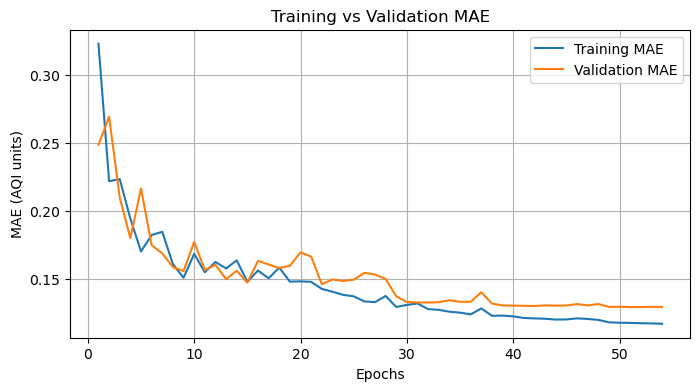

In [24]:
epochs = range(1, len(history.history['mae']) + 1)

plt.figure(figsize=(8, 4))

plt.plot(epochs, history.history['mae'], label='Training MAE')
plt.plot(epochs, history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('MAE (AQI units)')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()


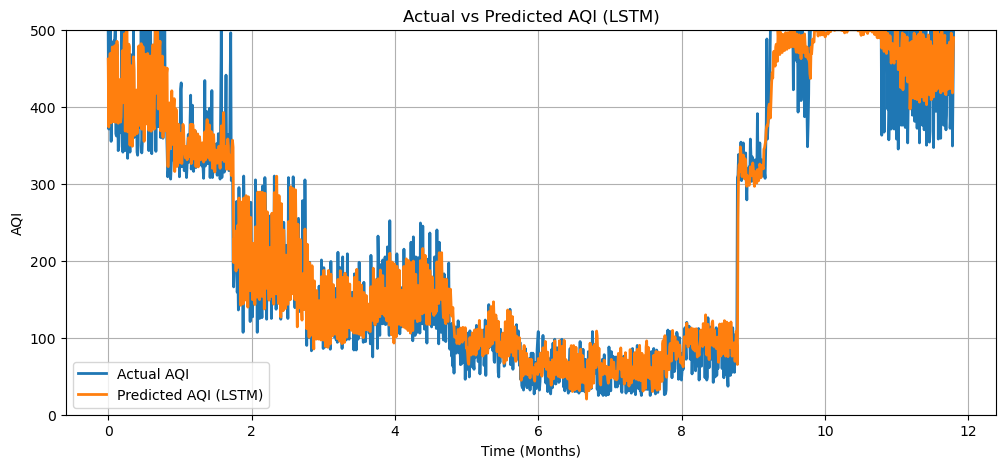

In [25]:
plt.figure(figsize=(12, 5))

# clip predictions to AQI range
y_pred_lstm = np.clip(y_pred_lstm, 0, 500)

# use correct length (same as plotted data)
n_samples = len(y_test_actual)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months, y_test_actual, label='Actual AQI', linewidth=2)
plt.plot(x_months, y_pred_lstm, label='Predicted AQI (LSTM)', linewidth=2)


# keep axis consistent with AQI definition
plt.ylim(0, 500)

plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI (LSTM)')
plt.legend()
plt.grid(True)

plt.savefig("lstm_actual_vs_predicted.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [26]:
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

drop_cols = ['aqi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']


In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost MAE: 21.520156860351562
XGBoost RMSE: 29.20295988784249


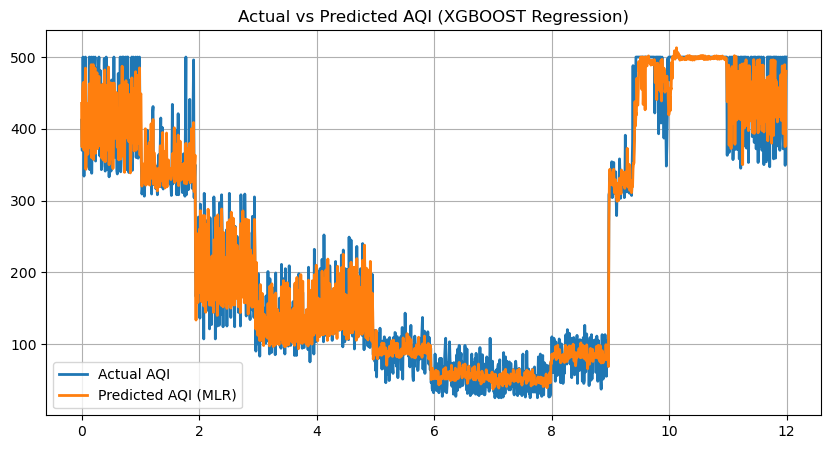

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred_xgb, label="Predicted AQI (MLR)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (XGBOOST Regression)")
plt.show()


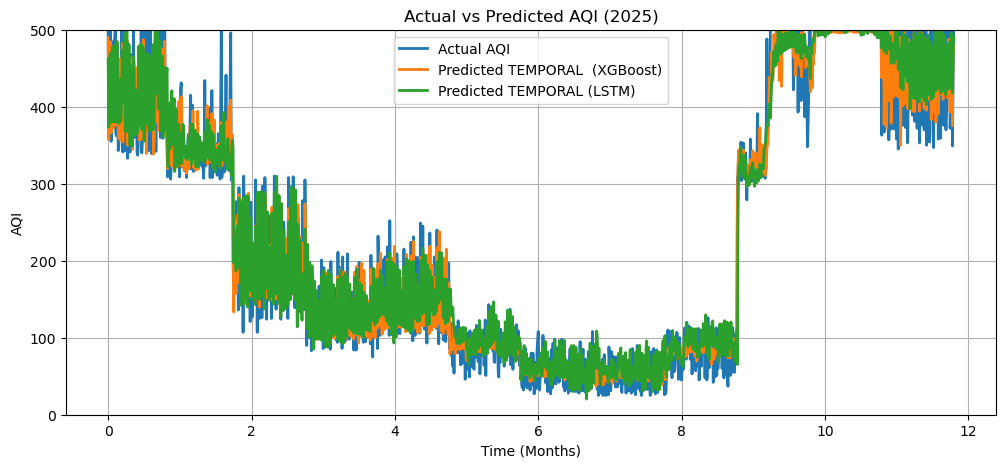

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Convert everything to numpy arrays
y_actual = np.array(y_test_actual)

y_xgb    = np.array(y_pred_xgb)
y_lstm   = np.array(y_pred_lstm)

# Find minimum length
min_len = min(len(y_actual), len(y_lstm), len(y_xgb))

# Align from the END (important for time series)
y_actual = y_actual[-min_len:]
y_lstm   = y_lstm[-min_len:]
y_xgb    = y_xgb[-min_len:]

# X-axis
x_months = np.arange(min_len) / 121.66

plt.figure(figsize=(12, 5))

plt.plot(x_months, y_actual, label='Actual AQI', linewidth=2)

plt.plot(x_months, y_xgb, label='Predicted TEMPORAL  (XGBoost)', linewidth=2)

plt.plot(x_months, y_lstm, label='Predicted TEMPORAL (LSTM)', linewidth=2)

plt.ylim(0, 500)
plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI (2025)')
plt.legend()
plt.grid(True)
plt.savefig("LSTMVSXG.jpg")
plt.show()
